# 1. Entendimento do Negócio (Business Understanding)
1. Contexto do Problema
O banco realizou campanhas de marketing direto (ligações telefônicas) para oferecer um produto financeiro: o Depósito a Prazo (Term Deposit).

2. Objetivo de Negócio
Objetivo Principal: Aumentar a taxa de conversão da campanha de marketing bancário, identificando quais clientes têm maior propensão a assinar o depósito a prazo.

Objetivo Secundário (Eficiência Operacional): Reduzir os custos de telemarketing, evitando ligar para clientes com baixíssima probabilidade de conversão.

3. Variável Target
y: Indica se o cliente contratou o depósito a prazo ('yes' ou 'no').

## Perguntas de Negócio a ser respondidas:

- Perfil Sociodemográfico: Qual faixa etária, profissão, nível educacional e estado civil apresentam a maior taxa de conversão?

- Histórico Financeiro/Risco: Clientes com empréstimo habitacional (housing), empréstimo pessoal (loan) ou histórico de inadimplência (default) têm menor disposição para investir em depósitos a prazo?

- Esforço de Campanha: Existe um ponto de saturação no número de contatos (campaign) a partir do qual insistir na ligação reduz a chance de conversão?

- Recência e Histórico de Campanhas Anteriores: Clientes que já foram contactados em campanhas passadas (pdays, previous, poutcome) têm maior propensão de conversão?

- Contexto Macroeconômico: Como variáveis de mercado (taxa Euribor a 3 meses, índice de confiança do consumidor, variação no emprego) influenciam a tomada de decisão do cliente?

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Configuração de Visualização (Visualizar todas as colunas)
pd.set_option('display.max_columns', None)

# Leitura dos Dados
caminho = r'..\data\raw\bank-additional-full.csv'
df = pd.read_csv(caminho, sep=';', encoding='latin1')

# 2. Entendimento dos Dados (Data Understanding)

In [14]:
display(df.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [15]:
# Tamanho da Base
print(f'Quantidade de Linhas: {df.shape[0]}')
print(f'Quantidade de Variáveis: {df.shape[1]}')

Quantidade de Linhas: 41188
Quantidade de Variáveis: 21


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [17]:
def visualizar_metadados(df) -> pd.DataFrame:
    """
    Função para visualizar Metadados de um Dataframe.
    return: Tipo, Cardinalidade, Qtd de Nulos e Percent Nulos
    param: Dataframe fornecido para análise
    """

    metadata = pd.DataFrame({
        'nome_variavel': df.columns,
        'tipo': df.dtypes,
        'qtd_nulos': df.isnull().sum(),
        'percent_nulos': round(df.isnull().sum() / len(df) * 100, 2),
        'cardinalidade': df.nunique()
    })

    metadata = metadata.sort_values(ascending=False, by='cardinalidade')
    metadata = metadata.reset_index(drop=True)

    return metadata

In [18]:
visualizar_metadados(df)

,nome_variavel,tipo,qtd_nulos,percent_nulos,cardinalidade
0,duration,int64,0,0.0,1544
1,euribor3m,float64,0,0.0,316
2,age,int64,0,0.0,78
3,campaign,int64,0,0.0,42
4,pdays,int64,0,0.0,27
5,cons.price.idx,float64,0,0.0,26
6,cons.conf.idx,float64,0,0.0,26
7,job,str,0,0.0,12
8,nr.employed,float64,0,0.0,11
9,emp.var.rate,float64,0,0.0,10


In [ ]:
# Transformando o target em Variável Binária INT
df['y'] = df['y'].replace('no', '0').replace('yes', '1').astype(int)
print(f'O tipo da variável target é: {df['y'].dtypes}')

O tipo da variável target é: int64


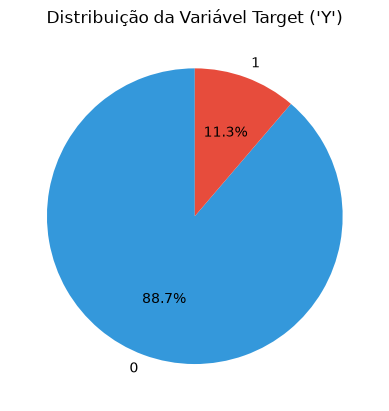

In [42]:
# Contagem das repostas (yes e no)
contagem_y = df['y'].value_counts()    
cores = ['#3498db', '#e74c3c']

plt.pie(contagem_y,
        labels=contagem_y.index,
        colors=cores,
        autopct='%1.1f%%',
        startangle=90) # Grau da fatia de menor valor

plt.title("Distribuição da Variável Target ('Y')")
plt.show()

In [59]:
# Mapeamento dos valores 'Unknown'
cols_categorias = df.select_dtypes(include=['string', 'object'])

unknown_df = pd.DataFrame({
    'coluna':cols_categorias.columns, # nome das colunas que tem o registro 'unknown'
    'pct_unknown':[(df[col] == 'unknown').mean() * 100 for col in cols_categorias.columns] # Cálculo de Porcentagem da palavra 'unknown' por variável
}).sort_values(by='pct_unknown', ascending=False)

print('=== MAPEAMENTO DE VALORES UNKNOWN POR VARIÁVEL ===')
print(unknown_df[unknown_df['pct_unknown'] > 0].astype('object'))

=== MAPEAMENTO DE VALORES UNKNOWN POR VARIÁVEL ===
      coluna pct_unknown
3    default   20.872584
2  education     4.20268
4    housing    2.403613
5       loan    2.403613
0        job    0.801204
1    marital    0.194231


## 📊 Relatório de Entendimento dos Dados (Data Understanding)

## 1. Visão Geral da Base
* **Volume de Dados:** A base possui **41.188 registros** e **21 variáveis**.
* **Ausência de Nulos Estruturais:** Não há registros do tipo `NaN` ou `None`.
* **Valores Ausentes Implícitos:** Existem dados faltantes registrados explicitamente sob a categoria `'unknown'` em colunas categóricas.

---

## 2. Diagnóstico da Variável Target (`y`)
* **Definição:** Indica se o cliente contratou o depósito a prazo (`'yes'` ou `'no'`).
* **Desbalanceamento de Classe:** A base apresenta forte desbalanceamento de classes (~88,7% de `'no'` e ~11,3% de `'yes'`).
* **Impacto na Modelagem:** A acurácia simples não será uma métrica adequada para avaliar os modelos; utilizar-se-á ROC-AUC, PR-AUC, F1-Score e matriz de confusão.

---

## 3. Mapeamento de Informações Ausentes (`'unknown'`)
Análise da proporção de dados não declarados/desconhecidos por coluna:

* **`default` (20,87% 'unknown'):** A ausência da informação de histórico de inadimplência representa $1/5$ da base. Esse desconhecimento é uma característica preditiva de negócio e não deve ser imputado por moda, mantendo-se como categoria própria.
* **`education` (4,20% 'unknown'):** Nível instrucional não informado.
* **`housing` (2,40% 'unknown') e `loan` (2,40% 'unknown'):** Status de crédito imobiliário ou pessoal não informado.
* **`job` (0,80% 'unknown') e `marital` (0,19% 'unknown'):** Ruídos residuais de cadastro de menor impacto volumétrico.

---

## 4. Ponto Crítico de Integridade de Negócio (*Data Leakage*)
* ⚠️ **Variável `duration`:** A duração do último contato em segundos possui altíssima correlação com a conversão do target.
* **Decisão Metodológica:** A coluna `duration` **será descartada antes do treinamento dos modelos preditivos**, pois seu valor só é conhecido *após* a realização da chamada telefônica. Mantê-la inviabilizaria o uso prático do modelo para decidir previamente para quem ligar.

---

## 5. Principais Comportamentos Identificados nas Variáveis

### 5.1. Histórico de Campanhas Anteriores
* **`pdays`:** O valor `999` indica clientes que nunca foram contactados em campanhas anteriores. A conversão é substancialmente diferente entre clientes recorrentes e novos contatos.
* **`poutcome`:** O resultado da campanha anterior é um dos maiores sinalizadores de propensão. Clientes com histórico de sucesso (`'success'`) apresentam taxa de conversão expressivamente superior à média.

### 5.2. Perfil Sociodemográfico e Educacional
* **`education`:** Variável categórica ordinal contendo hierarquia clara de escolaridade:
  $$\text{illiterate} < \text{basic.4y} < \text{basic.6y} < \text{basic.9y} < \text{high.school} < \text{professional.course} < \text{university.degree}$$
* **`job`:** A taxa de adesão varia fortemente de acordo com a ocupação (ex.: aposentados e estudantes vs. trabalhadores braçais/`blue-collar`).


# 3 - Análise Exploratória dos Dados (Data Analysis)

## Análise de Correlação

In [63]:
# Visualizar correlação das variáveis
print('=== Matriz de Correlação de Pearson ===')

# Selecionando colunas numéricas
cols_numericas = df.select_dtypes(include=[np.number]).columns

# Calculando a Matriz de Correlação de Pearson
matriz_corr = df[cols_numericas].corr()

corr_target = matriz_corr['y'].sort_values(ascending=False)
print(corr_target)


=== Matriz de Correlação de Pearson ===
y                 1.000000
duration          0.405274
previous          0.230181
cons.conf.idx     0.054878
age               0.030399
campaign         -0.066357
cons.price.idx   -0.136211
emp.var.rate     -0.298334
euribor3m        -0.307771
pdays            -0.324914
nr.employed      -0.354678
Name: y, dtype: float64


<Axes: >

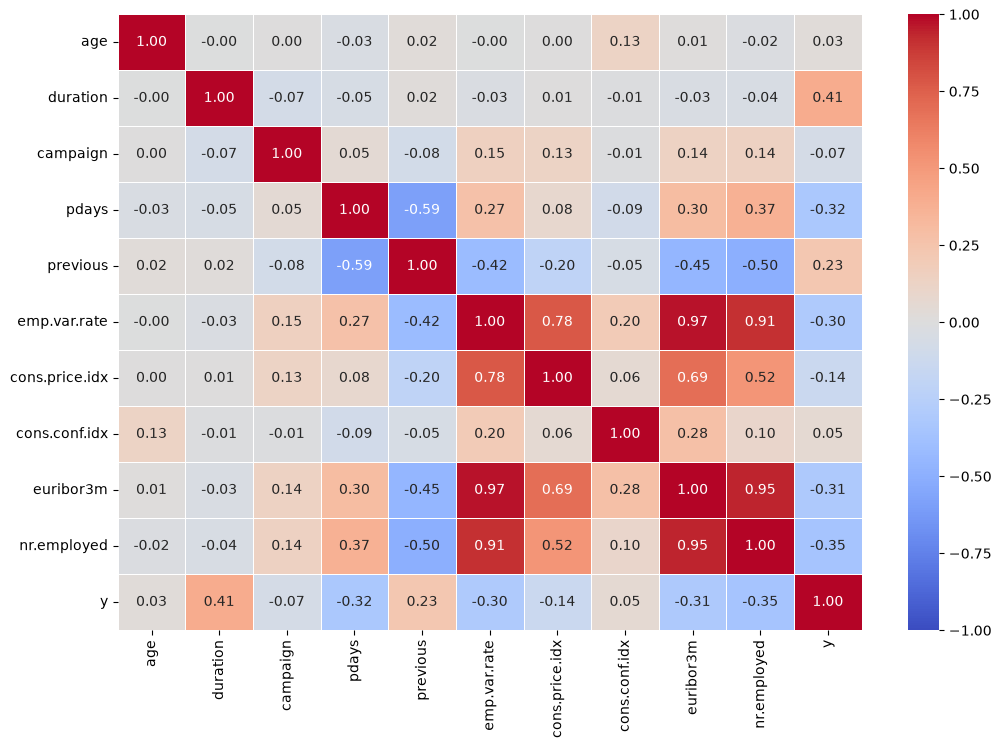

In [68]:
# Gerar o Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)